# Head Egocentric: 3 Spike Types (Any pass_100)

This notebook generates per-cell summary figures for **head direction** using all/simple/complex spike runs.

Selection rule:
- keep a cell if it passes `pass_100` in **at least one** of: `head_all_spike`, `head_simple_spike`, `head_complex_spike`.

Figure behavior updates:
- Column 3, row 2/3 use SS/CS fitted references and red arrows
- Column 4 includes SS and CS empirical-vs-fitted tuning subplots


In [1]:
from pathlib import Path
import subprocess
import sys
import os 

BASE_DIR = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4')
ROOT = BASE_DIR / 'data' / 'egocentric_tuning_carpenter_first10'
MANIFEST_DIR = ROOT
ANY_PASS_THRESHOLD = 100
ANY_PASS_SUFFIX = f'any{ANY_PASS_THRESHOLD}'
OUT_DIR = ROOT / f'head_{ANY_PASS_SUFFIX}_three_spike_compare'
SCRIPT = BASE_DIR / 'notebooks_HPC' / 'run_egocentric_plot_cells_head_three_spike_any99.py'

CANDIDATES = [
    Path(sys.executable),
    Path('/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/bin/python'),
    Path('/opt/homebrew/Caskroom/miniforge/base/envs/adamlab_pipeline/bin/python'),
]

def has_modules(py):
    if not py.exists() or not os.access(py, os.X_OK):
        return False
    code = 'import numpy,pandas,matplotlib,scipy;print("ok")'
    res = subprocess.run([str(py), '-c', code], capture_output=True, text=True)
    return res.returncode == 0

PYTHON_EXEC = None
for c in CANDIDATES:
    if has_modules(c):
        PYTHON_EXEC = str(c)
        break
if PYTHON_EXEC is None:
    raise RuntimeError('No suitable Python interpreter with required packages found.')

print('Python:', PYTHON_EXEC)
print('Script:', SCRIPT)
print('Output:', OUT_DIR)


Python: /opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/bin/python
Script: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/notebooks_HPC/run_egocentric_plot_cells_head_three_spike_any99.py
Output: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare


In [2]:
cmd = [
    PYTHON_EXEC,
    str(SCRIPT),
    '--base-dir', str(ROOT),
    '--manifest-dir', str(MANIFEST_DIR),
    '--output-dir', str(OUT_DIR),
    '--all-run', 'head_all_spike',
    '--ss-run', 'head_simple_spike',
    '--cs-run', 'head_complex_spike',
    '--data-root', str(BASE_DIR / 'data'),
    '--spatial-cache-root', str(BASE_DIR / 'data'),
    '--figures-root', str(BASE_DIR / 'figures'),
    '--direction-mode', 'head',
    '--any-pass-threshold', str(ANY_PASS_THRESHOLD),
    '--first-n-minutes', '20',
    '--save-formats', 'svg',
]
print('$ ' + ' '.join(cmd))
res = subprocess.run(cmd, cwd=str(BASE_DIR.parent), capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print(res.stderr)
    raise RuntimeError(f'Command failed with code {res.returncode}')
if res.stderr:
    print('[stderr]')
    print(res.stderr)

print('Figures saved to:', OUT_DIR)

$ /opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/bin/python /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/notebooks_HPC/run_egocentric_plot_cells_head_three_spike_any99.py --base-dir /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10 --manifest-dir /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10 --output-dir /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare --all-run head_all_spike --ss-run head_simple_spike --cs-run head_complex_spike --data-root /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data --spatial-cache-root /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data --figures-root /Users/qixinyang

In [3]:
import pandas as pd

per_cell_root = OUT_DIR / 'per_cell_summary'
manifest_csv = per_cell_root / f'egocentric_per_cell_plot_manifest_{ANY_PASS_SUFFIX}_3spike.csv'
skip_csv = per_cell_root / f'egocentric_per_cell_plot_skipped_{ANY_PASS_SUFFIX}_3spike.csv'

if not manifest_csv.exists():
    raise FileNotFoundError(f'Missing manifest: {manifest_csv}')

df = pd.read_csv(manifest_csv)
print('Manifest rows:', len(df))
print('By category:')
print(df['category'].value_counts(dropna=False))
print('Any-pass contributors:')
print(df[[f'pass{ANY_PASS_THRESHOLD}_all', f'pass{ANY_PASS_THRESHOLD}_ss', f'pass{ANY_PASS_THRESHOLD}_cs']].sum())
n_svg = len(list(per_cell_root.rglob('*.svg')))
n_png = len(list(per_cell_root.rglob('*.png')))
print('SVG files:', n_svg)
print('PNG files:', n_png)
if n_png > 0:
    raise AssertionError('Expected SVG-only outputs, but PNG files were found.')
print('Manifest CSV:', manifest_csv)
print('Skip CSV:', skip_csv)


Manifest rows: 23
By category:
category
CSplus        12
CSminus        8
all-nonPLC     3
Name: count, dtype: int64
Any-pass contributors:
pass100_all    6
pass100_ss     4
pass100_cs     3
dtype: int64
SVG files: 23
PNG files: 0
Manifest CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/per_cell_summary/egocentric_per_cell_plot_manifest_any100_3spike.csv
Skip CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/per_cell_summary/egocentric_per_cell_plot_skipped_any100_3spike.csv


## Behavior Head-Direction Tuning (6 Animals)

Overall behavior head-direction occupancy tuning using the same filtering settings as this analysis run:
- `direction_mode='head'`
- `n_angle_bins=10`
- `speed in [3, 60] cm/s`
- `first_n_minutes=10`


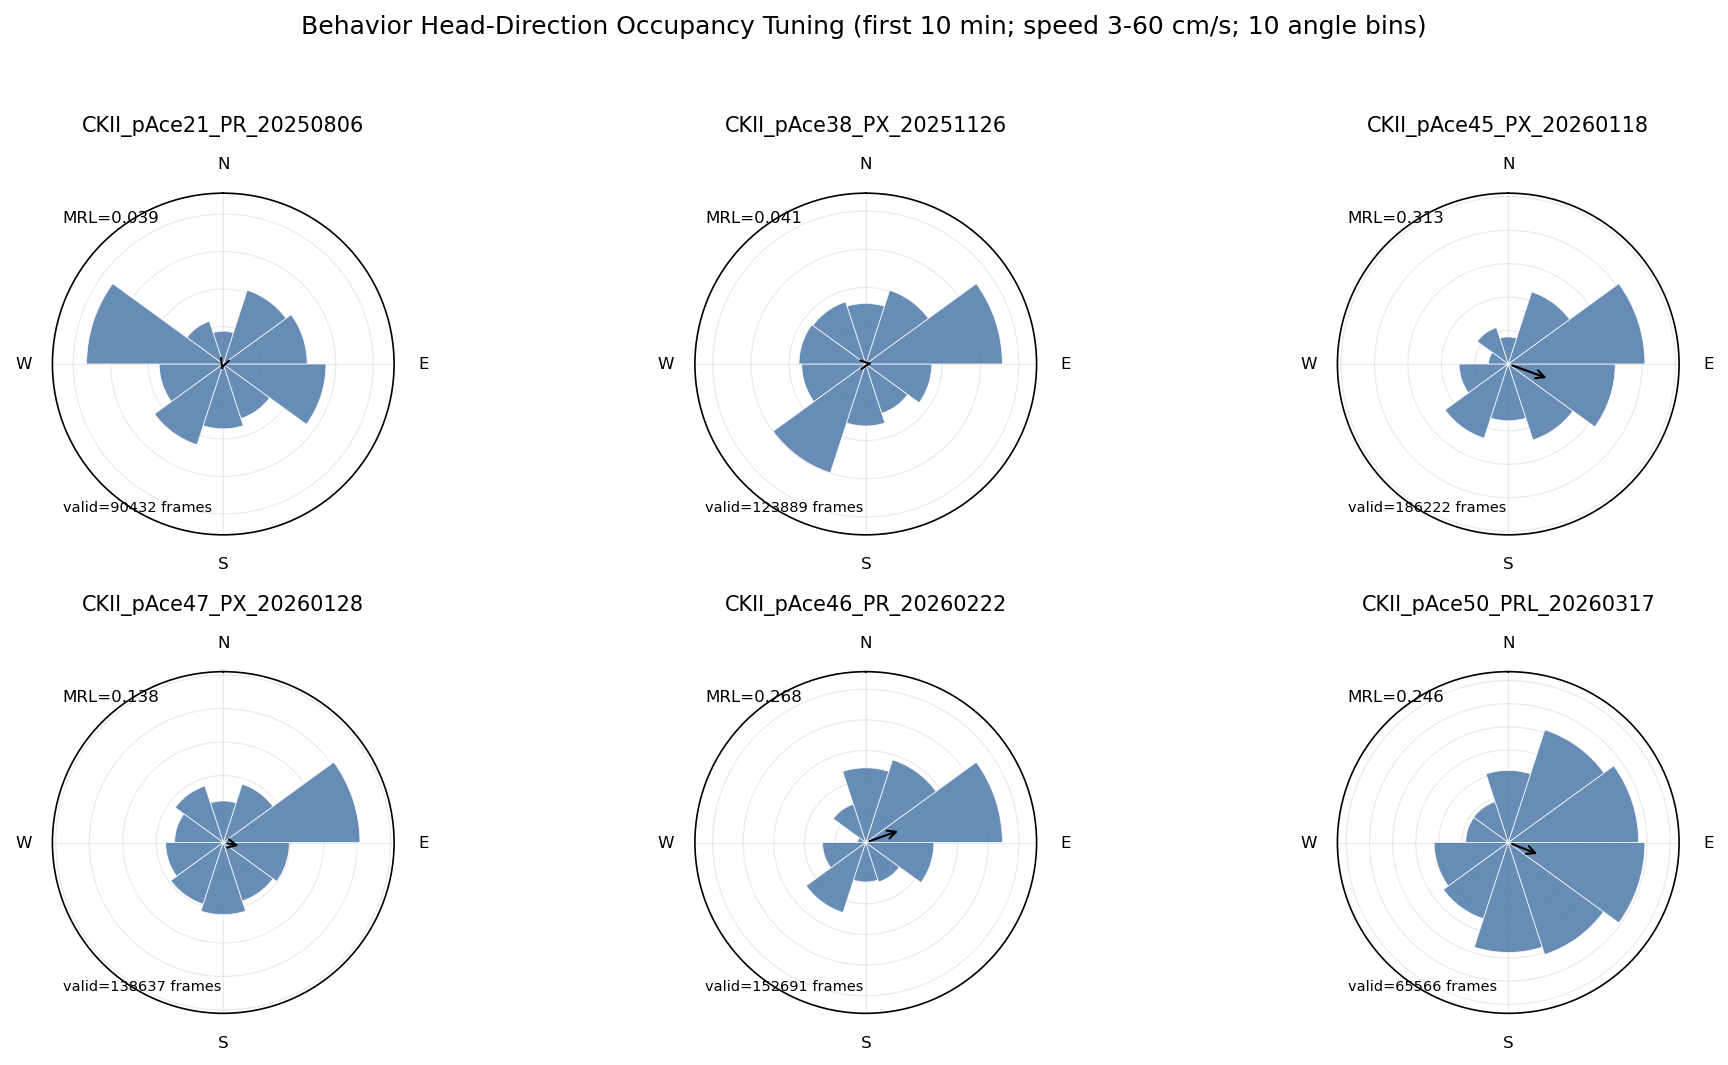

In [4]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ANIMALS = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
    'CKII_pAce50_PRL_20260317',
]

N_ANGLE_BINS = 10
FIRST_N_MINUTES = 10.0
SPEED_MIN = 3.0
SPEED_MAX = 60.0
ARENA_SIZE_CM = (35.5, 20.0)

ANGLE_EDGES = np.linspace(-np.pi, np.pi, N_ANGLE_BINS + 1, dtype=float)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])
THETA_DISP = np.mod(ANGLE_CENTERS - (np.pi / 2.0), 2.0 * np.pi)
BAR_WIDTH = (2.0 * np.pi) / float(N_ANGLE_BINS)


def load_merged_data(animal_dir: Path) -> dict:
    primary = animal_dir / 'merged_aligned_data.pkl'
    fallback = animal_dir / 'merged_aligned_data_CS.pkl'
    src = primary if primary.exists() else fallback
    if not src.exists():
        raise FileNotFoundError(f'Missing merged data for {animal_dir.name}')
    with src.open('rb') as f:
        return pickle.load(f)


def wrap_to_pi(angle_rad):
    return (np.asarray(angle_rad, dtype=float) + np.pi) % (2.0 * np.pi) - np.pi


def coerce_hd_to_radians_wrapped(hd_values):
    hd_arr = np.asarray(hd_values, dtype=float).reshape(-1)
    finite = hd_arr[np.isfinite(hd_arr)]
    if finite.size == 0:
        return np.full(hd_arr.shape, np.nan, dtype=float)
    if float(np.nanmax(np.abs(finite))) > (np.pi * 1.25):
        return wrap_to_pi(np.deg2rad(hd_arr))
    return wrap_to_pi(hd_arr)


def build_head_direction_valid_mask(
    *,
    x_frames,
    y_frames,
    hd_frames,
    speed_frames,
    frame_rate,
    first_n_minutes,
    arena_size_cm,
    speed_min_cm_s,
    speed_max_cm_s,
):
    x_arr = np.asarray(x_frames, dtype=float).reshape(-1)
    y_arr = np.asarray(y_frames, dtype=float).reshape(-1)
    speed_arr = np.asarray(speed_frames, dtype=float).reshape(-1)
    dir_frames = coerce_hd_to_radians_wrapped(hd_frames)

    width_cm, height_cm = float(arena_size_cm[0]), float(arena_size_cm[1])
    in_bounds = (
        np.isfinite(x_arr) & np.isfinite(y_arr)
        & (x_arr >= 0.0) & (x_arr <= width_cm)
        & (y_arr >= 0.0) & (y_arr <= height_cm)
    )
    valid = (
        np.isfinite(x_arr)
        & np.isfinite(y_arr)
        & np.isfinite(dir_frames)
        & np.isfinite(speed_arr)
        & in_bounds
        & (speed_arr >= float(speed_min_cm_s))
        & (speed_arr <= float(speed_max_cm_s))
    )

    if first_n_minutes is not None:
        cutoff = int(np.floor(float(first_n_minutes) * 60.0 * float(frame_rate)))
        cutoff = max(1, min(int(x_arr.size), cutoff))
        if cutoff < int(x_arr.size):
            valid[cutoff:] = False

    return np.asarray(dir_frames, dtype=float), np.asarray(valid, dtype=bool)


fig, axes = plt.subplots(2, 3, subplot_kw={'projection': 'polar'}, figsize=(13.0, 7.2), dpi=150)
axes = axes.flatten()

for ax, animal_id in zip(axes, ANIMALS):
    merged = load_merged_data(BASE_DIR / 'data' / animal_id)

    x_frames = np.asarray(merged['x_neural'], dtype=float)
    y_frames = np.asarray(merged['y_neural'], dtype=float)
    hd_frames = np.asarray(merged.get('hd_angles_neural', np.full_like(x_frames, np.nan)), dtype=float)
    speed_frames = np.asarray(merged['speed'], dtype=float)
    frame_rate = float(merged['frame_rate'])

    dir_frames, valid_mask = build_head_direction_valid_mask(
        x_frames=x_frames,
        y_frames=y_frames,
        hd_frames=hd_frames,
        speed_frames=speed_frames,
        frame_rate=frame_rate,
        first_n_minutes=FIRST_N_MINUTES,
        arena_size_cm=ARENA_SIZE_CM,
        speed_min_cm_s=SPEED_MIN,
        speed_max_cm_s=SPEED_MAX,
    )

    dirs = np.asarray(dir_frames[valid_mask], dtype=float)
    dirs = dirs[np.isfinite(dirs)]

    counts, _ = np.histogram(dirs, bins=ANGLE_EDGES)
    occ_s = np.asarray(counts, dtype=float) / float(frame_rate)
    total_s = float(np.sum(occ_s))
    occ_frac = (occ_s / total_s) if total_s > 0 else np.zeros_like(occ_s)

    ax.bar(
        THETA_DISP,
        occ_frac,
        width=BAR_WIDTH,
        align='center',
        color='#4C78A8',
        edgecolor='white',
        linewidth=0.4,
        alpha=0.85,
        zorder=2,
    )

    if dirs.size > 0:
        vec = np.mean(np.exp(1j * dirs))
        if np.isfinite(np.real(vec)) and np.isfinite(np.imag(vec)):
            mrl = float(np.clip(np.abs(vec), 0.0, 1.0))
            theta_mean = float(np.mod(np.angle(vec) - (np.pi / 2.0), 2.0 * np.pi))
            r_top = float(max(np.max(occ_frac) * 1.05, 1e-6))
            ax.annotate(
                '',
                xy=(theta_mean, r_top * mrl),
                xytext=(theta_mean, 0.0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.0),
                zorder=4,
            )
            ax.text(0.03, 0.95, f'MRL={mrl:.3f}', transform=ax.transAxes, ha='left', va='top', fontsize=8)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(1)
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(['N', 'W', 'S', 'E'], fontsize=8)
    ax.set_yticklabels([])
    ax.set_ylim(0.0, float(max(np.max(occ_frac) * 1.25, 0.05)))
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_title(animal_id, fontsize=10, pad=12)
    ax.text(0.03, 0.06, f'valid={int(np.sum(valid_mask))} frames', transform=ax.transAxes, ha='left', va='bottom', fontsize=7)

fig.suptitle(
    'Behavior Head-Direction Occupancy Tuning (first 10 min; speed 3-60 cm/s; 10 angle bins)',
    fontsize=12,
    y=0.98,
)
plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
plt.show()


## SS vs CS Valid-Bin Mean MRL Comparison

Comparison uses per-cell values shown in column 8 titles (Valid-bin mean MRL), with inclusion criterion:
- `valid_bin_mrl_n_ss >= 4` and `valid_bin_mrl_n_cs >= 4`


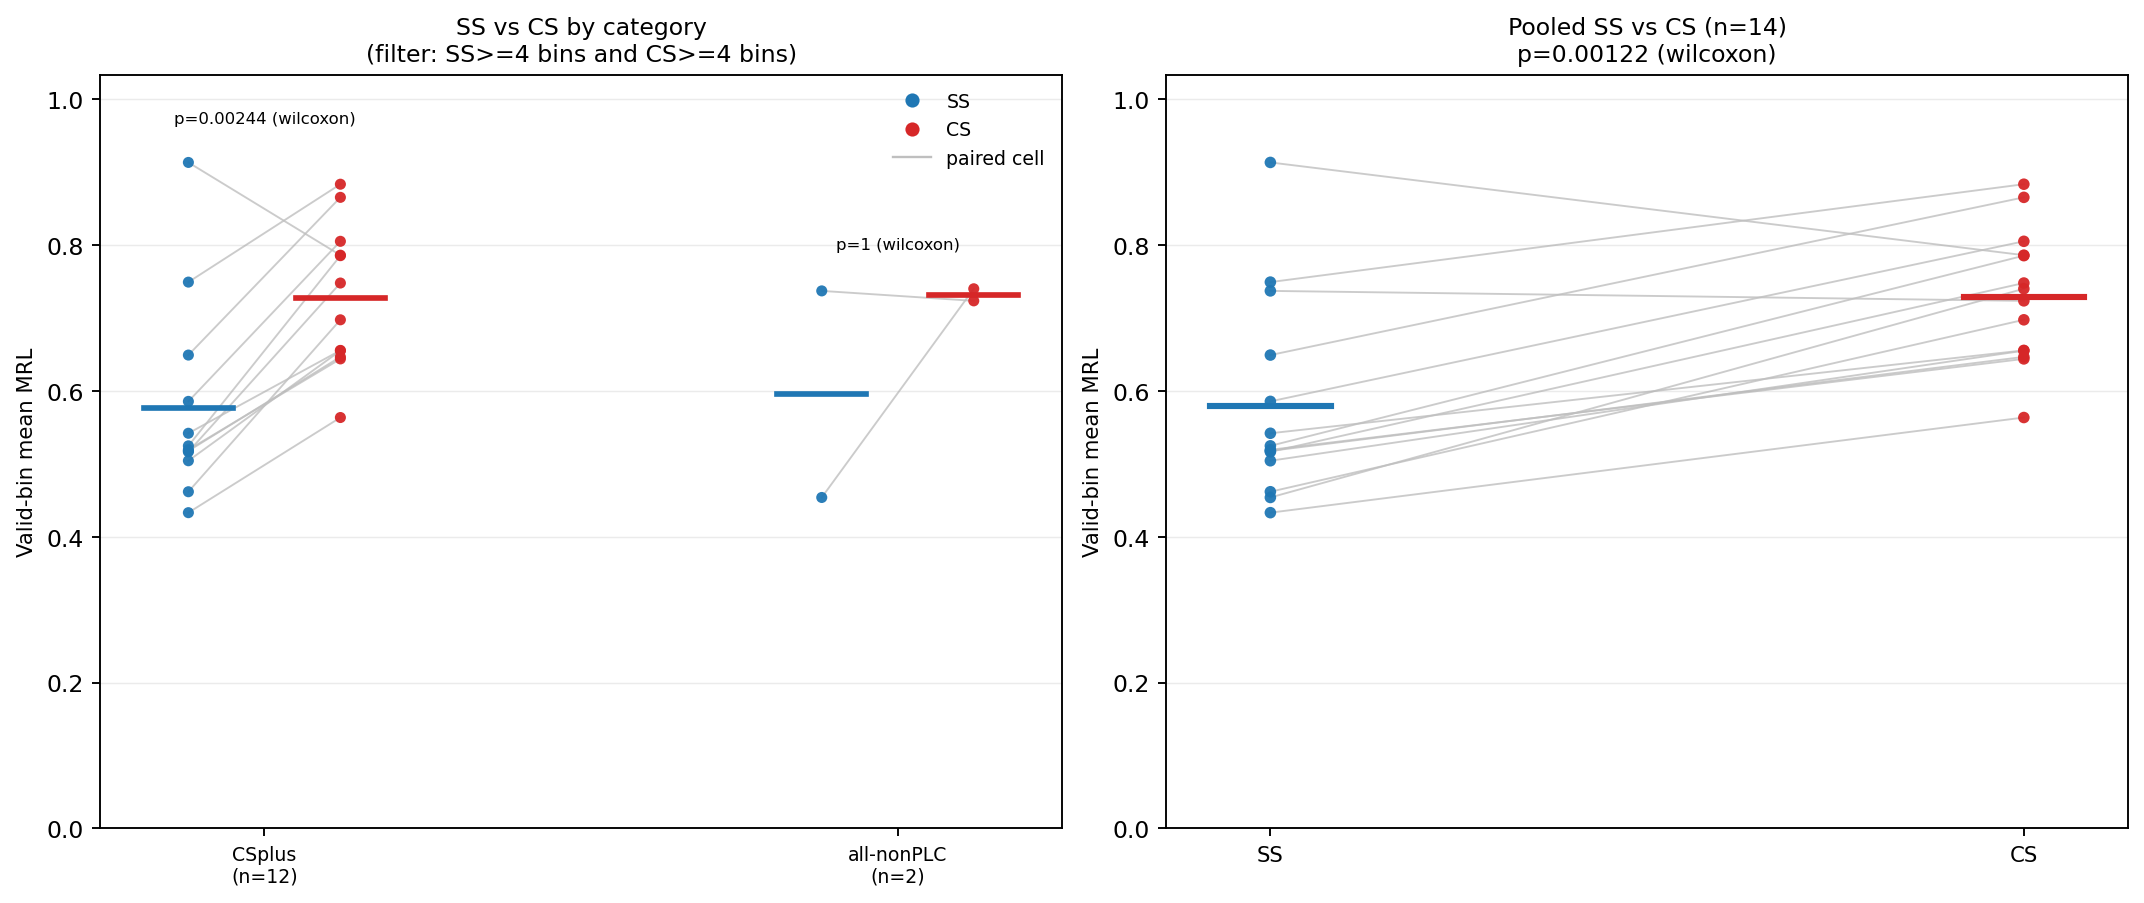

Included cells: 14
Included by category:
category
CSplus        12
all-nonPLC     2
Name: count, dtype: int64
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/summary_stats/egocentric_valid_bin_mean_mrl_ss_vs_cs.svg


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D

manifest_csv = OUT_DIR / 'per_cell_summary' / f'egocentric_per_cell_plot_manifest_{ANY_PASS_SUFFIX}_3spike.csv'
df = pd.read_csv(manifest_csv)

required_cols = [
    'category',
    'valid_bin_mean_mrl_ss',
    'valid_bin_mean_mrl_cs',
    'valid_bin_mrl_n_ss',
    'valid_bin_mrl_n_cs',
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(
        f"Missing required manifest columns: {missing}. "
        "Re-run the plotting cell to regenerate manifest with these fields."
    )

for c in ['valid_bin_mean_mrl_ss', 'valid_bin_mean_mrl_cs', 'valid_bin_mrl_n_ss', 'valid_bin_mrl_n_cs']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

cmp_df = df[
    np.isfinite(df['valid_bin_mean_mrl_ss'])
    & np.isfinite(df['valid_bin_mean_mrl_cs'])
    & (df['valid_bin_mrl_n_ss'] >= 4)
    & (df['valid_bin_mrl_n_cs'] >= 4)
].copy()

if cmp_df.empty:
    raise RuntimeError('No cells pass SS/CS valid-bin filter (>=4 each).')

preferred_order = ['CSplus', 'CSminus', 'all-nonPLC']
categories = [c for c in preferred_order if c in set(cmp_df['category'])]
for c in sorted(set(cmp_df['category'])):
    if c not in categories:
        categories.append(c)


def paired_pvalue(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = x.size
    if n < 2:
        return np.nan, 'n<2'
    if np.allclose(x - y, 0.0, atol=1e-12, rtol=0.0):
        return 1.0, 'all_equal'
    try:
        p = float(stats.wilcoxon(x, y, alternative='two-sided', zero_method='wilcox').pvalue)
        return p, 'wilcoxon'
    except Exception:
        p = float(stats.ttest_rel(x, y, nan_policy='omit').pvalue)
        return p, 'ttest_rel'


fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), dpi=170, constrained_layout=True)
ax_cat, ax_pool = axes

# -------- Subplot 1: per-category --------
cat_ns = []
for i, cat in enumerate(categories):
    sub = cmp_df.loc[cmp_df['category'] == cat].copy()
    ss = sub['valid_bin_mean_mrl_ss'].to_numpy(dtype=float)
    cs = sub['valid_bin_mean_mrl_cs'].to_numpy(dtype=float)
    n = int(min(ss.size, cs.size))
    cat_ns.append(n)
    if n <= 0:
        continue

    for j in range(n):
        ax_cat.plot([i - 0.12, i + 0.12], [ss[j], cs[j]], color='0.75', lw=0.8, alpha=0.8, zorder=1)

    ax_cat.scatter(np.full(n, i - 0.12), ss, s=22, c='#1F77B4', edgecolors='none', alpha=0.95, zorder=2)
    ax_cat.scatter(np.full(n, i + 0.12), cs, s=22, c='#D62728', edgecolors='none', alpha=0.95, zorder=2)

    mean_ss = float(np.nanmean(ss))
    mean_cs = float(np.nanmean(cs))
    ax_cat.plot([i - 0.19, i - 0.05], [mean_ss, mean_ss], color='#1F77B4', lw=2.4, zorder=3)
    ax_cat.plot([i + 0.05, i + 0.19], [mean_cs, mean_cs], color='#D62728', lw=2.4, zorder=3)

    p_val, test_name = paired_pvalue(ss, cs)
    if np.isfinite(p_val):
        y_txt = max(np.nanmax(ss), np.nanmax(cs)) + 0.05
        ax_cat.text(i, y_txt, f'p={p_val:.3g} ({test_name})', ha='center', va='bottom', fontsize=7)

xticklabels = [f'{cat}\n(n={n})' for cat, n in zip(categories, cat_ns)]
ax_cat.set_xticks(np.arange(len(categories), dtype=float))
ax_cat.set_xticklabels(xticklabels, fontsize=8)
ax_cat.set_ylabel('Valid-bin mean MRL', fontsize=9)
ax_cat.set_title('SS vs CS by category\n(filter: SS>=4 bins and CS>=4 bins)', fontsize=10)
ax_cat.grid(axis='y', alpha=0.25, linewidth=0.6)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', color='none', markerfacecolor='#1F77B4', markeredgecolor='none', markersize=6, label='SS'),
    Line2D([0], [0], marker='o', linestyle='none', color='none', markerfacecolor='#D62728', markeredgecolor='none', markersize=6, label='CS'),
    Line2D([0], [0], color='0.75', lw=1.0, label='paired cell'),
]
ax_cat.legend(handles=legend_handles, loc='best', fontsize=8, frameon=False)

# -------- Subplot 2: pooled --------
ss_all = cmp_df['valid_bin_mean_mrl_ss'].to_numpy(dtype=float)
cs_all = cmp_df['valid_bin_mean_mrl_cs'].to_numpy(dtype=float)
mask_all = np.isfinite(ss_all) & np.isfinite(cs_all)
ss_all = ss_all[mask_all]
cs_all = cs_all[mask_all]
n_all = int(ss_all.size)

for j in range(n_all):
    ax_pool.plot([0.0, 1.0], [ss_all[j], cs_all[j]], color='0.75', lw=0.8, alpha=0.8, zorder=1)

ax_pool.scatter(np.zeros(n_all), ss_all, s=24, c='#1F77B4', edgecolors='none', alpha=0.95, zorder=2)
ax_pool.scatter(np.ones(n_all), cs_all, s=24, c='#D62728', edgecolors='none', alpha=0.95, zorder=2)

mean_ss_all = float(np.nanmean(ss_all)) if n_all > 0 else np.nan
mean_cs_all = float(np.nanmean(cs_all)) if n_all > 0 else np.nan
if np.isfinite(mean_ss_all):
    ax_pool.plot([-0.08, 0.08], [mean_ss_all, mean_ss_all], color='#1F77B4', lw=2.6, zorder=3)
if np.isfinite(mean_cs_all):
    ax_pool.plot([0.92, 1.08], [mean_cs_all, mean_cs_all], color='#D62728', lw=2.6, zorder=3)

p_pool, pool_test = paired_pvalue(ss_all, cs_all)
title_pool = f'Pooled SS vs CS (n={n_all})'
if np.isfinite(p_pool):
    title_pool += f'\np={p_pool:.3g} ({pool_test})'
ax_pool.set_title(title_pool, fontsize=10)
ax_pool.set_xticks([0.0, 1.0])
ax_pool.set_xticklabels(['SS', 'CS'], fontsize=9)
ax_pool.set_ylabel('Valid-bin mean MRL', fontsize=9)
ax_pool.grid(axis='y', alpha=0.25, linewidth=0.6)

all_plot_vals = np.concatenate([ss_all, cs_all]) if n_all > 0 else np.array([0.0])
ymax = float(np.nanmax(all_plot_vals)) if np.any(np.isfinite(all_plot_vals)) else 1.0
ymax = max(0.25, min(1.05, ymax + 0.12))
for ax in (ax_cat, ax_pool):
    ax.set_ylim(0.0, ymax)

summary_dir = OUT_DIR / 'summary_stats'
summary_dir.mkdir(parents=True, exist_ok=True)
out_svg = summary_dir / 'egocentric_valid_bin_mean_mrl_ss_vs_cs.svg'
fig.savefig(out_svg, format='svg', bbox_inches='tight')
plt.show()

print('Included cells:', len(cmp_df))
print('Included by category:')
print(cmp_df['category'].value_counts())
print('Saved:', out_svg)



## DRZ Preferred vs Non-Preferred Traversals (CS+ EB-tuned)

Trial-by-trial DRZ analysis for **CS+ EB-tuned** cells selected from `per_cell_summary/CSplus` SVGs.
Traversal classes are **P** (preferred) and **NP** (non-preferred), using green-bin logic from column 8 (row 1, all-spike empirical panel).


In [6]:
import importlib
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd

_top_repo = str(BASE_DIR.parent.resolve())
sys.path[:] = [p for p in sys.path if os.path.normpath(p) != os.path.normpath(_top_repo)]
sys.path.insert(0, str(BASE_DIR.resolve()))
os.environ['PYTHONPATH'] = str(BASE_DIR.resolve())

import utils.placecell_pipeline as _pcp
from utils.spatial_heatmaps import classify_spatial_cells

importlib.reload(_pcp)

preferred_fraction_threshold = 0.5
preferred_half_width_deg = 50.0
min_covered_green_bins = 1
classification_drz_segment_mode = 'all'
classification_phase_signed_drz_filter = True

ANIMALS = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
    'CKII_pAce50_PRL_20260317',
]

config = _pcp.PipelineConfig(
    project_root=BASE_DIR,
    data_root=BASE_DIR / "data",
    figures_root=BASE_DIR / "figures",
    notebooks_root=BASE_DIR / "notebooks_PCs",
    animals=ANIMALS,
    analysis=_pcp.AnalysisParams(
        speed_threshold=3.0, speed_threshold_quiet=0.5, min_duration_s=0.25,
        merge_gap_s=0.0, kernel_size=51, snr_threshold=3.0, min_good_minutes=5.0,
        theta_freqs=(4.0, 8.0), slow_freqs=2.0,
    ),
    place_cell=_pcp.PlaceCellParams(
        bin_size=1.5, place_field_threshold=0.35, min_component_peak_ratio=0.45,
        split_multi_peak_fields=True, split_secondary_peak_ratio=0.6,
        split_secondary_peak_min_separation_cm=6.0, min_peak_rate=0.5,
        max_field_area_ratio=0.5, min_field_bins=10, min_pf_firing_traversals=5,
        pf_firing_traversal_distance_window_cm=15.0,
        pf_firing_traversal_detection_window_cm=8.0,
        pf_firing_traversal_distance_bin_cm=1.5,
        pf_firing_traversal_distance_mode="euclidean_to_peak",
        pf_firing_traversal_center_vicinity_min_cm=1,
        pf_firing_traversal_center_vicinity_max_cm=5,
        pf_firing_traversal_resting_speed_threshold=0.5,
        pf_firing_traversal_merge_gap_s=2.0,
        pf_firing_traversal_exclude_trials_with_bad_frames=True,
        pf_reliability_dilation_bins=3,
        pf_reliability_dilation_shape="disk", smooth_sigma=1.5, min_occupancy_s=0.001,
        occ_smooth_sigma=1.5, num_shuffles=1000, random_seed=42,
        ss_shape_min_separation_ms=14.0, trim_sparse_top_row_for_analysis=True,
        trim_sparse_top_row_for_plotting=True, sparse_top_row_nonocc_frac_threshold=0.8,
    ),
    traversal=_pcp.PFTraversalParams(
        center_by_pf_position=True, pf_component_selection="peak_rate",
        min_duration_ms=100.0, min_distance_cm=5.0, traversal_merge_gap_s=2.0,
        clear_traversal=False, session_indices=(0, 1), pf_center_window_sec=10.0,
        min_traversals=10, firing_rate_bin_ms=100.0, firing_rate_smooth_ms=50.0,
        subtract_pre_traversal_baseline=False, mask_non_traversal_pf=True,
        max_pf_distance_cm=8.0, plateau_min_duration_ms=100.0,
    ),
    pooled=_pcp.PooledParams(
        cb_num_threshold=5, cs_peak_rate_threshold=0.5, cs_plc_definition_mode="cs_place_field",
        run_psd_sections=True,
        cs_plc_only=True, psd_speed_threshold=3, psd_chunk_s=2.0, psd_nperseg_s=1.0,
        psd_noverlap_frac=0.5, simple_event_window_ms=80.0, simple_event_min_gap_ms=50.0,
        min_chunk_valid_fraction=1.0, max_freq=100.0, normalize_psd=True,
        norm_freq_range=(20.0, 100.0),
    ),
    cache=_pcp.CachePolicy(force_recompute=False, validate_only=False, save_executed_notebooks=False),
)

spatial_data = classify_spatial_cells(
    data_folder=str(BASE_DIR / "data"),
    folders=config.animals,
    cb_num_threshold=config.pooled.cb_num_threshold,
    cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
    cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
    snr_threshold=config.analysis.snr_threshold,
)

drz_params = _pcp.PFDRZParams(
    trial_distance_window_cm=20.0,
    trial_detection_window_cm=6.0,
    trial_clip_mode="pf_entry_exit",
    drz_window=1.0,
    drz_bin=0.1,
    distance_mode="euclidean_to_peak",
    min_traversals=10,
    min_traversals_per_type=5,
    subtract_pre_traversal_baseline=False,
    exclude_trials_with_bad_frames=True,
    pf_component_selection="peak_rate",
    max_pf_distance_cm=8.0,
    smooth_window=0.0,
    center_vicinity_min_cm=1,
    center_vicinity_max_cm=5,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    resting_speed_threshold=0.5,
    include_long_cb_as_plateau=True,
    include_resting_plateaus=True,
    phase_signed_drz_filter=True,
    cb_plateau_min_duration_ms=150.0,
    first_n_minutes=10.0,
)

drz_trial_plot_dilation_bins = 4
drz_trial_plot_dilation_shape = config.place_cell.pf_reliability_dilation_shape

drz_pnp_out_dir = OUT_DIR / "drz_preferred_nonpreferred"
drz_pnp_result = _pcp.generate_drz_trials_and_dataset_egocentric_preferred_nonpreferred(
    config=config,
    spatial_data=spatial_data,
    drz_params=drz_params,
    egocentric_base_dir=ROOT,
    csplus_svg_dir=OUT_DIR / "per_cell_summary" / "CSplus",
    figure_save_folder=drz_pnp_out_dir,
    preferred_fraction_threshold=preferred_fraction_threshold,
    preferred_half_width_deg=preferred_half_width_deg,
    min_covered_green_bins=min_covered_green_bins,
    classification_frame_selection_mode='nonrest',
    classification_drz_segment_mode=classification_drz_segment_mode,
    classification_phase_signed_drz_filter=classification_phase_signed_drz_filter,
    pf_reliability_dilation_bins=drz_trial_plot_dilation_bins,
    pf_reliability_dilation_shape=drz_trial_plot_dilation_shape,
    plot_figures=True,
    show_plots=False,
    save_summary_csv=True,
    debug_mode=False,
)

drz_pnp_dataset = drz_pnp_result.get("dataset", {})
drz_pnp_summary = drz_pnp_result.get("plot_summary", {})
print("Output dir:", drz_pnp_summary.get("output_dir"))
print("Summary CSV:", drz_pnp_summary.get("summary_csv"))
print("Selected cells:", drz_pnp_summary.get("n_selected_cells"))


Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 9 cells from CKII_pAce38_PX_20251126
Loaded 15 cells from CKII_pAce45_PX_20260118
Loaded 5 cells from CKII_pAce47_PX_20260128
Loaded 9 cells from CKII_pAce46_PR_20260222
Loaded 9 cells from CKII_pAce50_PRL_20260317

Total: 56 cells loaded
Output dir: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_preferred_nonpreferred/PF_drz_trials_CSplus_PLCs_egocentric_pnp
Summary CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_preferred_nonpreferred/PF_drz_trials_csplus_egocentric_pnp_summary.csv
Selected cells: 0


In [7]:
from pathlib import Path
import pandas as pd

summary_csv = Path(drz_pnp_summary.get("summary_csv", ""))
out_dir = Path(drz_pnp_summary.get("output_dir", ""))
if not summary_csv.exists():
    raise FileNotFoundError(f"Missing summary CSV: {summary_csv}")
if not out_dir.exists():
    raise FileNotFoundError(f"Missing output dir: {out_dir}")

df = pd.read_csv(summary_csv)
print("Summary rows:", len(df))
if len(df) > 0:
    print(df["status"].value_counts(dropna=False))
    show_cols = [
        "animal_id", "cell_idx", "pf_rank", "status",
        "n_detected_traversals", "n_classified_traversals",
        "n_preferred_traversals", "n_nonpreferred_traversals", "n_unclassified_traversals",
    ]
    show_cols = [c for c in show_cols if c in df.columns]
    print(df[show_cols].head(20).to_string(index=False))

svg_files = sorted(out_dir.rglob("*.svg"))
png_files = sorted(out_dir.rglob("*.png"))
print("SVG files:", len(svg_files))
print("PNG files:", len(png_files))
if len(png_files) > 0:
    raise AssertionError("Expected SVG-only outputs for DRZ P/NP analysis.")

selected_svg_cells = sorted((OUT_DIR / "per_cell_summary" / "CSplus").glob("*.svg"))
print("Selected CSplus SVG cells:", len(selected_svg_cells))
print("Summary CSV:", summary_csv)
print("Output folder:", out_dir)


Summary rows: 0
SVG files: 0
PNG files: 0
Selected CSplus SVG cells: 0
Summary CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_preferred_nonpreferred/PF_drz_trials_csplus_egocentric_pnp_summary.csv
Output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_preferred_nonpreferred/PF_drz_trials_CSplus_PLCs_egocentric_pnp


## DRZ Compare Directions (Preferred vs Non-preferred)

Run the DRZ compare-directions workflow using explicit `all/p/np` channels from `drz_pnp_dataset`.

In [8]:
import importlib
from pathlib import Path
import pandas as pd

import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

if not isinstance(drz_pnp_dataset, dict) or len(drz_pnp_dataset) == 0:
    raise RuntimeError('drz_pnp_dataset is missing. Run the DRZ P/NP generation cell first.')

PNP_DIRECTION_KEYS = ('all', 'p', 'np')
PNP_DIRECTION_TITLES = ('All', 'Preferred', 'Non-preferred')
drz_direction_avg_mode_pnp = 's1'
drz_smooth_window_pnp = 0.3
drz_avg_smooth_window_pnp = 0.0

drz_window = float(drz_pnp_dataset.get('metadata', {}).get('drz_window', 1.0))
drz_display_xlim_pnp = (-drz_window, drz_window)

pnp_compare_root = OUT_DIR / 'drz_compare_directions_pnp'
pnp_heatmap_root = pnp_compare_root / 'per_cell_heatmaps'
pnp_average_export_subdir = 'pf_drz_pnp_2directions_average_exports'
pnp_average_export_dir = pnp_heatmap_root / pnp_average_export_subdir

print('PNP direction keys:', PNP_DIRECTION_KEYS)
print('Avg mode:', drz_direction_avg_mode_pnp)
print('Smooth window (cm):', drz_smooth_window_pnp)
print('Avg smooth window (cm):', drz_avg_smooth_window_pnp)
print('Compare root:', pnp_compare_root)
print('Heatmap root:', pnp_heatmap_root)
print('Average export dir:', pnp_average_export_dir)


PNP direction keys: ('all', 'p', 'np')
Avg mode: s1
Smooth window (cm): 0.3
Avg smooth window (cm): 0.0
Compare root: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp
Heatmap root: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/per_cell_heatmaps
Average export dir: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/per_cell_heatmaps/pf_drz_pnp_2directions_average_exports


### Heatmap

In [9]:
drz_pnp_heatmap_summary_2directions = _pcp.generate_pf_drz_component_heatmaps_2directions(
    dataset=drz_pnp_dataset,
    figure_save_folder=pnp_heatmap_root,
    clear_output=True,
    smooth_window=float(drz_smooth_window_pnp),
    fr_vmax_scale=0.2,
    theta_vlim=(0, 0.4),
    slow_vlim=(-0.4, 0.4),
    fig_width=3.0,
    trial_height=0.01,
    xlim=drz_display_xlim_pnp,
    merge_ss_cs=True,
    merge_plateau=True,
    smooth_plateau=False,
    plateau_vlim=0.01,
    avg_smooth_window=float(drz_avg_smooth_window_pnp),
    show_session_gap_line=True,
    avg_mode=drz_direction_avg_mode_pnp,
    save_average_exports=True,
    average_export_subdir=pnp_average_export_subdir,
    output_prefix='pf_drz_pnp_2directions',
    direction_keys=PNP_DIRECTION_KEYS,
    direction_titles=PNP_DIRECTION_TITLES,
    show_plot=False,
)

for cat, info in drz_pnp_heatmap_summary_2directions.items():
    print(f'{cat} summary (P/NP 2 directions): {info}')


CSplus summary (P/NP 2 directions): {'output_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/per_cell_heatmaps/pf_drz_pnp_2directions_CSplus_heatmaps', 'output_dir_uri': 'file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/per_cell_heatmaps/pf_drz_pnp_2directions_CSplus_heatmaps', 'n_primary_entries': 0, 'n_secondary_entries': 0, 'n_union_entries': 0, 'n_pf2_only_entries': 0, 'n_saved_files': 0, 'n_dual_pf_files': 0, 'mode': 'direction_heatmap_with_avg_mode', 'avg_mode': 's1', 'average_export_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/per_cell_heatmaps/pf

### Average Plot

In [10]:
cat = 'CSplus'
out_path = pnp_compare_root / 'pf_drz_CSplus_average_primary_secondary_pnp_2directions.svg'
fig = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2directions(
    dataset=drz_pnp_dataset,
    category=cat,
    title='CS+ PLCs (Preferred vs Non-preferred)',
    out_path=out_path,
    smooth_window=float(drz_smooth_window_pnp),
    avg_smooth_window=float(drz_avg_smooth_window_pnp),
    plot_trials=True,
    trial_alpha=0.2,
    trial_linewidth=0.5,
    theta_ylim=(0, 0.2),
    slow_ylim=(-0.05, 0.2),
    fr_ylim_scale=1.2,
    ss_cs_ylim_scale=1.2,
    figsize_per_block=(3.4, 2.4),
    xlim=drz_display_xlim_pnp,
    fr_row_ylim_max=1.5,
    ss_cs_row_ylim_max=1.1,
    min_traversals_per_type=int(drz_params.min_traversals_per_type),
    use_saved_average_exports=True,
    average_export_dir=pnp_average_export_dir,
    avg_mode=drz_direction_avg_mode_pnp,
    enforce_min_traversals_on_saved_exports=True,
    direction_keys=PNP_DIRECTION_KEYS,
    direction_titles=PNP_DIRECTION_TITLES,
    explicit_preferred_nonpreferred_keys=('p', 'np'),
    show_plot=True,
)
print('Generated:', out_path)
_ = fig


No primary PF data to plot for CS+ PLCs (Preferred vs Non-preferred)
Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/pf_drz_CSplus_average_primary_secondary_pnp_2directions.svg


In [11]:
drz_pnp_directionality_results = _pcp.compute_pf_drz_pref_nonpref_stats(
    drz_pnp_dataset,
    timepoint_cm=0.0,
    min_traversals_per_type=int(drz_params.min_traversals_per_type),
    smooth_window_cm=0.0,
    auc_window_cm=None,
    slow_auc_window_cm=(-0.5, 0.5),
    peak_window_cm=(-0.5, 0.5),
    use_saved_average_exports=True,
    average_export_dir=pnp_average_export_dir,
    avg_mode=drz_direction_avg_mode_pnp,
    direction_keys=PNP_DIRECTION_KEYS,
    explicit_preferred_nonpreferred_keys=('p', 'np'),
)
print('Skipped counts:', drz_pnp_directionality_results.get('skipped_counts', {}))

drz_pnp_directionality_plot_summary = _pcp.plot_pf_drz_pref_nonpref_stats(
    drz_pnp_directionality_results,
    figure_save_folder=pnp_compare_root,
    show_plot=True,
    save_csv=True,
)
print('DRZ P/NP directionality outputs:')
for key, value in drz_pnp_directionality_plot_summary.items():
    print(f'  {key}: {value}')


[pref_nonpref_stability] No NaN metrics from flat/invalid traces after inclusion gating.
Skipped counts: {'missing': 0, 'low_traversals': 0, 'no_preferred': 0}
DRZ P/NP directionality outputs:


In [12]:
if not pnp_compare_root.exists():
    raise FileNotFoundError(f'Missing compare output dir: {pnp_compare_root}')

heatmap_svgs = sorted((pnp_heatmap_root).rglob('*.svg'))
avg_fig = pnp_compare_root / 'pf_drz_CSplus_average_primary_secondary_pnp_2directions.svg'
stats_csv = Path(drz_pnp_directionality_plot_summary.get('stats_csv', ''))
per_cell_csv = Path(drz_pnp_directionality_plot_summary.get('per_cell_csv', ''))
stats_fig = Path(drz_pnp_directionality_plot_summary.get('figure', ''))
stats_fig_sscs = Path(drz_pnp_directionality_plot_summary.get('figure_ss_cs', ''))

print('CSplus selected cells from SVG folder:', len(list((OUT_DIR / 'per_cell_summary' / 'CSplus').glob('*.svg'))))
print('Heatmap SVG count:', len(heatmap_svgs))
print('Average figure exists:', avg_fig.exists(), avg_fig)
print('Stats figure exists:', stats_fig.exists(), stats_fig)
print('Stats SS/CS figure exists:', stats_fig_sscs.exists(), stats_fig_sscs)
print('Per-cell CSV exists:', per_cell_csv.exists(), per_cell_csv)
print('Stats CSV exists:', stats_csv.exists(), stats_csv)

if not avg_fig.exists():
    raise FileNotFoundError(f'Missing average figure: {avg_fig}')
if not per_cell_csv.exists() or not stats_csv.exists():
    raise FileNotFoundError('Missing directionality CSV outputs.')

per_cell_df = pd.read_csv(per_cell_csv)
print('Per-cell stats rows:', len(per_cell_df))
if len(per_cell_df) > 0:
    print('direction_pref values:', sorted(per_cell_df['direction_pref'].dropna().astype(str).unique().tolist()))
    print('direction_nonpref values:', sorted(per_cell_df['direction_nonpref'].dropna().astype(str).unique().tolist()))

summary_csv = Path(drz_pnp_summary.get('summary_csv', ''))
if summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
    cols = [c for c in [
        'n_detected_traversals', 'n_classified_traversals',
        'n_preferred_traversals', 'n_nonpreferred_traversals', 'n_unclassified_traversals'
    ] if c in summary_df.columns]
    if cols:
        print('Traversal totals:', summary_df[cols].sum(numeric_only=True).to_dict())


CSplus selected cells from SVG folder: 0
Heatmap SVG count: 0
Average figure exists: False /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/pf_drz_CSplus_average_primary_secondary_pnp_2directions.svg
Stats figure exists: True .
Stats SS/CS figure exists: True .
Per-cell CSV exists: True .
Stats CSV exists: True .


FileNotFoundError: Missing average figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter_first10/head_any100_three_spike_compare/drz_compare_directions_pnp/pf_drz_CSplus_average_primary_secondary_pnp_2directions.svg